In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================
# PROJECT PATH
# ============================================

ROOT = Path(
    r"D:\My_Project\Analyse\capston Project_2-Global Supply Chain Risk & Logistics"
)


# ============================================
# DATA PATH
# ============================================

DATA_PATH = (
    ROOT
    / "data"
    / "interim"
    / "cleaned_data.csv"
)


# ============================================
# FIGURE PATH
# ============================================

FIGURE_PATH = (
    ROOT
    / "reports"
    / "figures"
)


# Create figures folder
FIGURE_PATH.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================
# LOAD DATA
# ============================================

df = pd.read_csv(DATA_PATH)


# ============================================
# CHECK DATA
# ============================================

print("Shape:", df.shape)

display(df.head())

Shape: (5000, 13)


,date,origin_port,destination_port,transport_mode,product_category,distance_km,weight_mt,fuel_price_index,geopolitical_risk_score,weather_condition,carrier_reliability_score,lead_time_days,disruption
0,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [2]:
df.columns

Index(['date', 'origin_port', 'destination_port', 'transport_mode',
       'product_category', 'distance_km', 'weight_mt', 'fuel_price_index',
       'geopolitical_risk_score', 'weather_condition',
       'carrier_reliability_score', 'lead_time_days', 'disruption'],
      dtype='str')

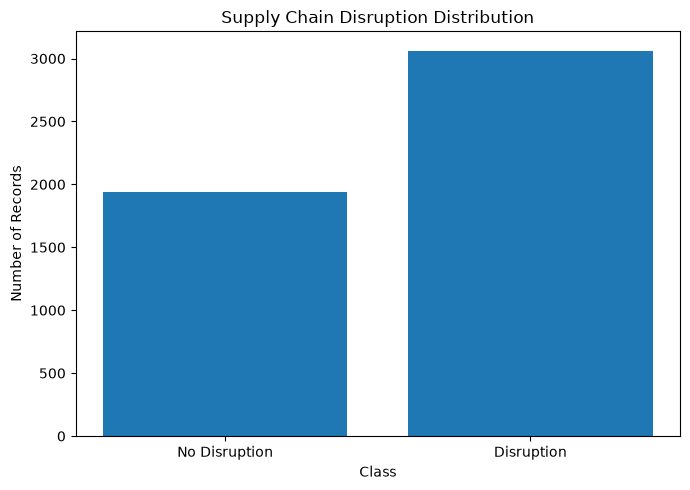

Target distribution:
disruption
0    1937
1    3063
Name: count, dtype: int64


In [3]:
# ============================================
# TARGET DISTRIBUTION
# ============================================

target_counts = (
    df["disruption"]
    .value_counts()
    .sort_index()
)


# ============================================
# CREATE BAR CHART
# ============================================

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Disruption", "Disruption"],
    [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
)


# ============================================
# CHART DETAILS
# ============================================

plt.title(
    "Supply Chain Disruption Distribution"
)

plt.xlabel("Class")

plt.ylabel("Number of Records")


plt.tight_layout()


# ============================================
# SAVE FIGURE
# ============================================

plt.savefig(
    FIGURE_PATH / "D:\\My_Project\\Analyse\\capston Project_2-Global Supply Chain Risk & Logistics\\screenshots\\target_distribution.png",
    dpi=200
)


# ============================================
# SHOW CHART
# ============================================

plt.show()


# ============================================
# PRINT COUNTS
# ============================================

print("Target distribution:")

print(target_counts)

In [4]:
numeric_columns = (
    df
    .select_dtypes(include=np.number)
    .columns
)

display(
    df[numeric_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
distance_km,5000.0,7704.063888,4199.687885,500.17,4036.010,7750.125,11347.4625,14995.91
weight_mt,5000.0,246.252052,142.522591,1.03,124.330,243.500,366.9550,499.75
fuel_price_index,5000.0,2.854552,0.959533,1.20,2.020,2.840,3.7100,4.50
geopolitical_risk_score,5000.0,5.076900,2.877832,0.00,2.600,5.100,7.5000,10.00
carrier_reliability_score,5000.0,0.754387,0.144363,0.50,0.629,0.757,0.8790,1.00
lead_time_days,5000.0,19.355386,31.405143,0.50,2.110,8.245,21.2075,236.39
disruption,5000.0,0.612600,0.487205,0.00,0.000,1.000,1.0000,1.00


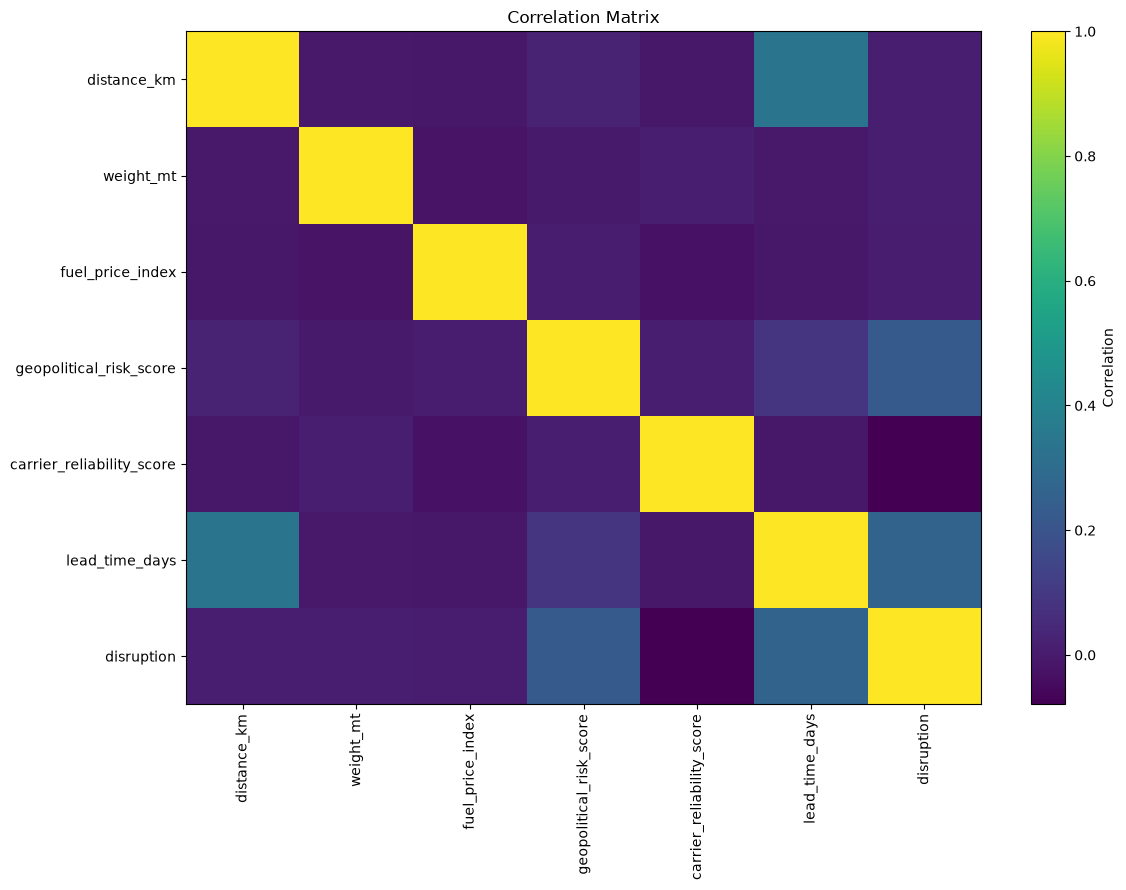

In [5]:
numeric_df = (
    df
    .select_dtypes(include=np.number)
)

correlation = numeric_df.corr()

plt.figure(figsize=(12, 9))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    FIGURE_PATH / "D:\\My_Project\\Analyse\\capston Project_2-Global Supply Chain Risk & Logistics\\screenshots\\correlation_matrix.png",
    dpi=200
)

plt.show()

In [6]:
categorical_columns = (
    df
    .select_dtypes(exclude=np.number)
    .columns
)

print("Categorical columns:")

for column in categorical_columns:

    print(
        f"\n{column}"
    )

    display(
        df[column]
        .value_counts()
        .head(10)
    )

Categorical columns:

date


date
2024-04-05    16
2024-10-29    16
2024-09-28    14
2024-05-20    14
2025-10-16    13
2025-01-24    13
2024-03-21    13
2024-06-10    13
2024-09-03    13
2025-03-09    13
Name: count, dtype: int64


origin_port


origin_port
Busan          667
Rotterdam      646
Shanghai       644
Antwerp        635
Dubai          610
Los Angeles    602
Singapore      599
Hamburg        597
Name: count, dtype: int64


destination_port


...

transport_mode
Air     1320
Sea     1281
Road    1214
Rail    1185
Name: count, dtype: int64


product_category


product_category
Electronics        1016
Textiles           1010
Perishables        1009
Pharmaceuticals    1006
Automotive          959
Name: count, dtype: int64


weather_condition


weather_condition
Fog          1036
Storm        1002
Clear         995
Hurricane     990
Rain          977
Name: count, dtype: int64